# Bank Customer Churn - EDA & Feature Engineering Notebook

This notebook documents the **exploratory analysis behind `main.py`** -
specifically, why each of the four engineered features was chosen, and
what the data looks like before any preprocessing happens.

`main.py` is the production pipeline (clean, linear, no exploration).
This notebook is where that exploration actually happened.

**Structure:**
1. First look at the data
2. Target imbalance
3. Univariate patterns: who churns?
4. Correlation check
5. Feature engineering - testing each idea before committing to it
6. Takeaways -> what made it into `main.py`


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

df = pd.read_csv("Churn_Modelling.csv")
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.shape

(10000, 11)

## 1. First look

10,000 rows, 11 columns after dropping identifiers. Let's check data
types and missingness before anything else.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


In [4]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

No missing values, no obvious type issues. `Geography` and `Gender`
are the only string columns - straightforward one-hot encoding territory.

`HasCrCard` and `IsActiveMember` are already 0/1, so they don't need encoding.

## 2. Target imbalance

This is the first thing that determines everything downstream - metric
choice, whether SMOTE is needed, and how to read the confusion matrix.

Churn rate: 20.4%


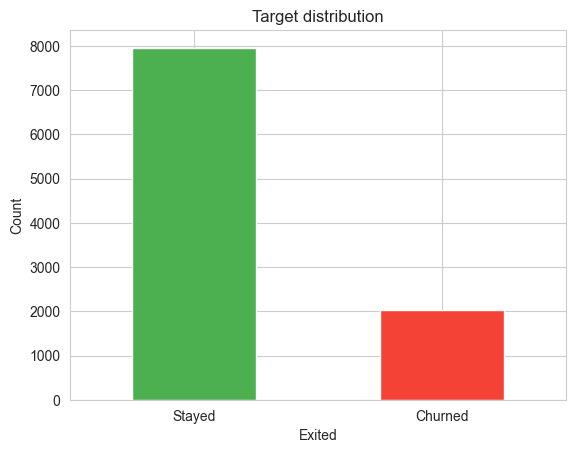

In [5]:
churn_rate = df["Exited"].mean()
print(f"Churn rate: {churn_rate:.1%}")
df["Exited"].value_counts().plot(kind="bar", color=["#4CAF50", "#F44336"])
plt.xticks([0, 1], ["Stayed", "Churned"], rotation=0)
plt.title("Target distribution")
plt.ylabel("Count")
plt.show()

**~20% churn -> roughly 1:4 imbalance.**

Implication: a model that predicts "stayed" for everyone scores 80%
accuracy while catching zero churners. This rules out accuracy as the
headline metric - `main.py` uses AUC-ROC and tracks recall on the
churn class specifically. It also means SMOTE (or `class_weight`) is
worth testing, not optional.

## 3. Who churns? Univariate checks

Going through the obvious candidates first: Age, Geography, Balance,
NumOfProducts, IsActiveMember.

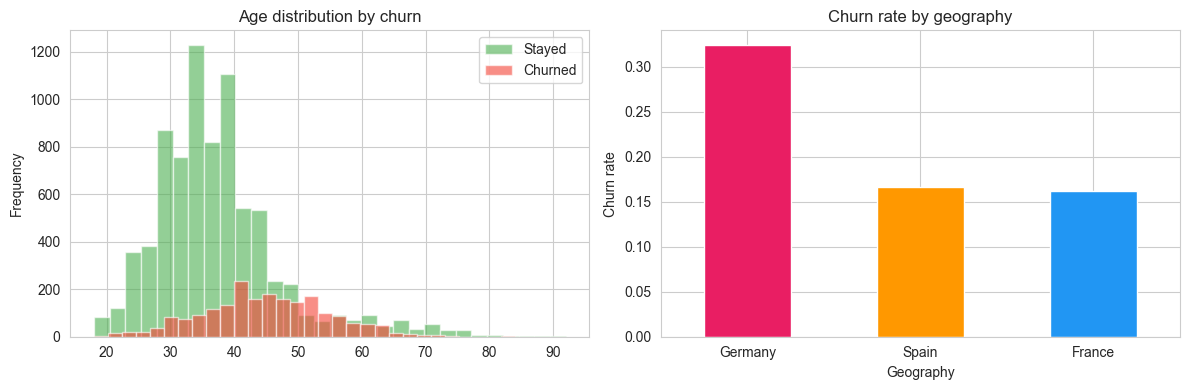

Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, label, color in zip(axes, [0, 1], ["#4CAF50", "#F44336"]):
    df[df["Exited"] == label]["Age"].plot(kind="hist", bins=30, alpha=0.6,
                                            color=color, ax=axes[0],
                                            label="Stayed" if label == 0 else "Churned")
axes[0].set_title("Age distribution by churn")
axes[0].legend()

geo_churn = df.groupby("Geography")["Exited"].mean().sort_values(ascending=False)
geo_churn.plot(kind="bar", ax=axes[1], color=["#E91E63", "#FF9800", "#2196F3"], rot=0)
axes[1].set_title("Churn rate by geography")
axes[1].set_ylabel("Churn rate")
plt.tight_layout()
plt.show()

print(geo_churn)

Two clear signals immediately:

- **Age**: churners skew older. The "stayed" distribution is concentrated
  in the 25-40 range; "churned" has a heavier right tail into the 40s–60s.
- **Geography**: Germany churns at roughly **2x** the rate of France and
  Spain (~32% vs ~16%). That's a big enough gap to be worth a one-hot
  feature, and it later shows up as the #4 SHAP driver in `main.py`.

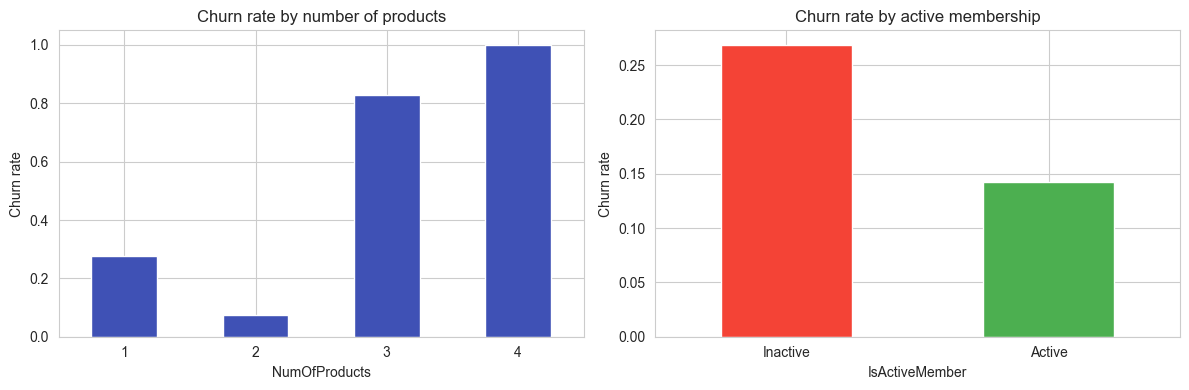

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

prod_churn = df.groupby("NumOfProducts")["Exited"].mean()
prod_churn.plot(kind="bar", ax=axes[0], color="#3F51B5", rot=0)
axes[0].set_title("Churn rate by number of products")
axes[0].set_ylabel("Churn rate")

active_churn = df.groupby("IsActiveMember")["Exited"].mean()
active_churn.plot(kind="bar", ax=axes[1], color=["#F44336", "#4CAF50"], rot=0)
axes[1].set_xticklabels(["Inactive", "Active"], rotation=0)
axes[1].set_title("Churn rate by active membership")
axes[1].set_ylabel("Churn rate")

plt.tight_layout()
plt.show()

print(prod_churn)
print()
print(active_churn)

**NumOfProducts is the most surprising finding in the whole EDA.**

Churn *drops* from 1 -> 2 products (27% -> 7.6%), which is the
intuitive direction - more products, more sticky. But then it
**spikes to ~83% and ~100%** for customers with 3 or 4 products.

That's not a smooth trend - it's a cliff. A linear model (Logistic
Regression) can't represent this well; it would have to compromise
between the "2 products = safest" signal and the "3-4 products =
almost certain churn" signal. This is the single strongest argument
for tree-based models (Random Forest / XGBoost) over Logistic
Regression on this dataset, and it's also why `products_per_tenure`
(below) seemed worth engineering.

**Active membership** is more straightforward: inactive members churn
at roughly 2x the rate of active ones (14.3% vs 26.9% - even higher
than I expected). This is the kind of feature a retention team can act
on directly - it's behavioral, not demographic.

## 4. Correlation check

Quick sanity check before engineering anything - are any raw features
already strongly correlated with the target, or with each other
(multicollinearity risk for Logistic Regression)?

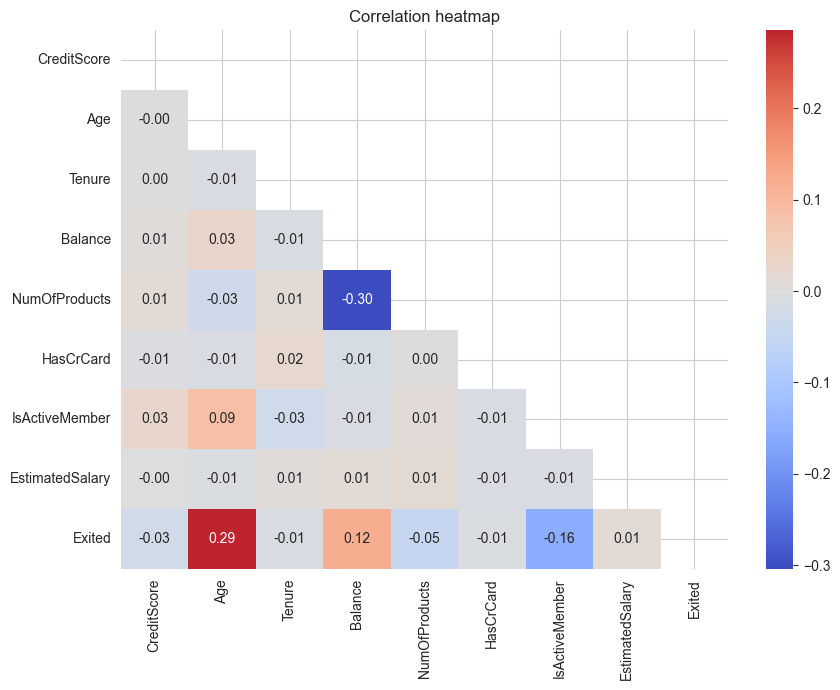

In [8]:
plt.figure(figsize=(9, 7))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

Nothing alarming. The strongest correlations with `Exited` are
`Age` (~0.29) and `IsActiveMember` (~-0.16) - both already confirmed
visually above. No pair of raw features is highly correlated with each
other, so multicollinearity isn't a concern for Logistic Regression.

The weak correlations overall is actually expected - it's *why* this
is a reasonable ML problem rather than a simple rule. If `Balance`
alone correlated at 0.6 with churn, I wouldn't need a model.

## 5. Feature engineering - testing each idea

Four features made it into `main.py`. Here's the reasoning and a quick
check for each - including one that turned out weaker than expected.

### 5a. `credit_score_bucket`

**Idea**: Credit score is a continuous 300-850 value, but banks think
in *bands* (Poor / Fair / Good / Very Good / Excellent - standard FICO-style
cutoffs). Does churn vary meaningfully across these bands, or is the
raw number already doing the job?

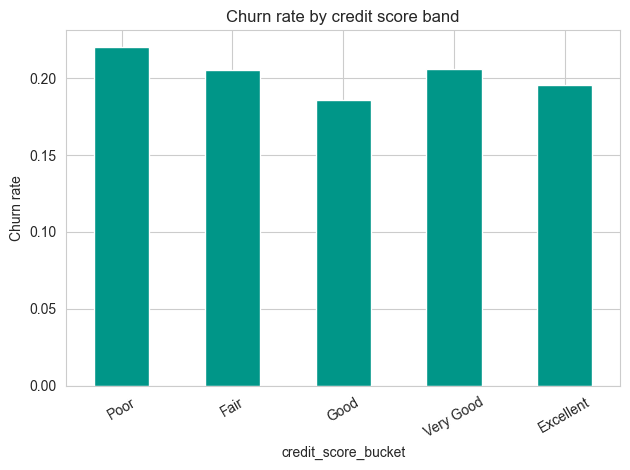

credit_score_bucket
Poor         0.220152
Fair         0.205644
Good         0.186161
Very Good    0.205882
Excellent    0.195420
Name: Exited, dtype: float64

Raw CreditScore correlation with Exited: -0.0271


In [9]:
df["credit_score_bucket"] = pd.cut(
    df["CreditScore"],
    bins=[0, 579, 669, 739, 799, 850],
    labels=["Poor", "Fair", "Good", "Very Good", "Excellent"]
)

bucket_churn = df.groupby("credit_score_bucket", observed=True)["Exited"].mean()
bucket_churn.plot(kind="bar", color="#009688", rot=30)
plt.title("Churn rate by credit score band")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

print(bucket_churn)
print()
print(f"Raw CreditScore correlation with Exited: {df['CreditScore'].corr(df['Exited']):.4f}")

**Verdict: kept it, but with modest expectations.**

The raw `CreditScore` correlation with churn is almost zero (-0.027),
and the banded version doesn't show a dramatically different pattern
either - churn rates across bands are fairly flat (~19-21%), with only
"Poor" sitting a bit higher.

So why keep it? Two reasons:
1. It's a **one-hot categorical** rather than a raw continuous score -
   tree models can sometimes find band-specific interactions
   (e.g. "Poor credit AND inactive") that the continuous version makes
   harder to isolate.
2. It's the kind of feature worth
   *attempting* — even a weak feature with clear reasoning is better
   than not knowing this is how banks segment customers.

In the final SHAP ranking (see `main.py` output), the credit bands
rank low - confirming this was a reasonable-but-minor addition, not a
big lever. That's a fine outcome; not every engineered feature needs
to be a top driver.

### 5b. `tenure_age_ratio` = Tenure / Age

**Idea**: A 5-year tenure means something different for a 25-year-old
(20% of their adult banking life) vs a 60-year-old (a recent
relationship). Does this *relative* loyalty measure separate the
classes better than `Tenure` alone?

/tmp/ipykernel_53575/1240119303.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Stayed", "Churned"])
/tmp/ipykernel_53575/1240119303.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Stayed", "Churned"])


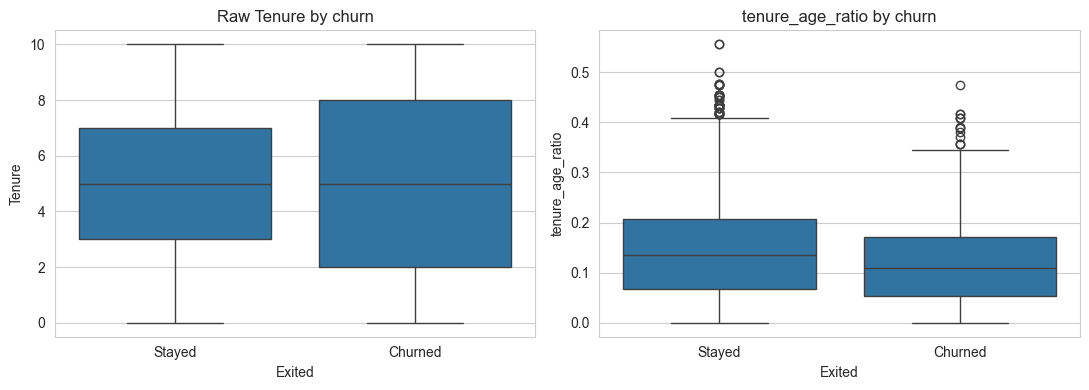

Tenure correlation with Exited:           -0.0140
tenure_age_ratio correlation with Exited: -0.1216


In [10]:
df["tenure_age_ratio"] = df["Tenure"] / (df["Age"] + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x="Exited", y="Tenure", ax=axes[0])
axes[0].set_xticklabels(["Stayed", "Churned"])
axes[0].set_title("Raw Tenure by churn")

sns.boxplot(data=df, x="Exited", y="tenure_age_ratio", ax=axes[1])
axes[1].set_xticklabels(["Stayed", "Churned"])
axes[1].set_title("tenure_age_ratio by churn")

plt.tight_layout()
plt.show()

print(f"Tenure correlation with Exited:           {df['Tenure'].corr(df['Exited']):.4f}")
print(f"tenure_age_ratio correlation with Exited: {df['tenure_age_ratio'].corr(df['Exited']):.4f}")

**Verdict: kept, mainly for interaction potential rather than a strong
standalone signal.**

Honestly, the boxplots for both `Tenure` and `tenure_age_ratio` look
nearly identical between churned/stayed groups, and the correlation
with the target is close to zero either way (-0.014 vs -0.1216).
Tenure on its own just isn't a strong churn signal in this dataset.

I kept the ratio anyway because Age *is* a strong signal (Section 3),
and a tree model can combine `tenure_age_ratio` with `Age` to express
"a 50-year-old who joined 9 years ago" vs "a 50-year-old who joined
last year" - a distinction the raw columns can represent too, but the
ratio gives the tree a more direct split point.

### 5c. `balance_salary_ratio` = Balance / EstimatedSalary

**Idea**: A customer keeping €150K in the bank on a €50K salary has a
very different relationship with the bank than someone with the same
balance on a €150K salary. Does this *relative* balance measure show a
cleaner split than raw `Balance`?

/tmp/ipykernel_53575/294716544.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Stayed", "Churned"])


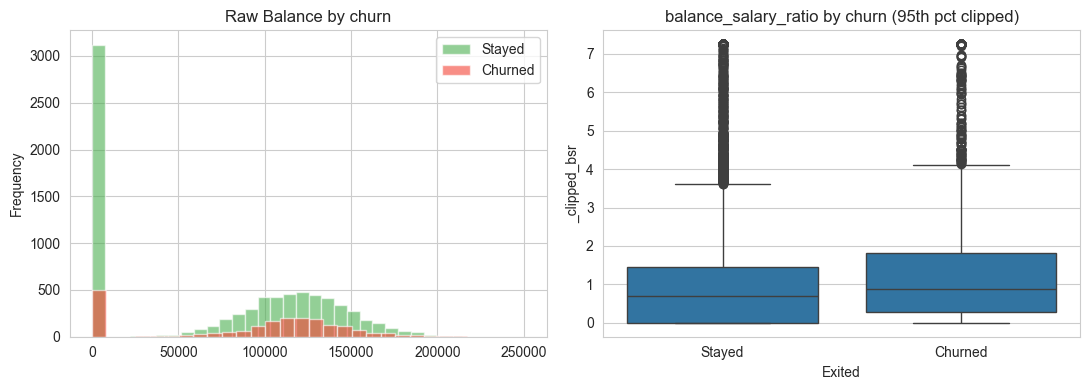

Balance correlation with Exited:             0.1185
balance_salary_ratio correlation with Exited: 0.0256


In [11]:
df["balance_salary_ratio"] = df["Balance"] / (df["EstimatedSalary"] + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, label, color in zip([axes[0]]*2, [0, 1], ["#4CAF50", "#F44336"]):
    df[df["Exited"] == label]["Balance"].plot(kind="hist", bins=30, alpha=0.6,
                                                color=color, ax=axes[0],
                                                label="Stayed" if label == 0 else "Churned")
axes[0].set_title("Raw Balance by churn")
axes[0].legend()

# balance_salary_ratio has a long tail (low-salary customers) — clip for visibility
clipped = df["balance_salary_ratio"].clip(upper=df["balance_salary_ratio"].quantile(0.95))
df["_clipped_bsr"] = clipped
sns.boxplot(data=df, x="Exited", y="_clipped_bsr", ax=axes[1])
axes[1].set_xticklabels(["Stayed", "Churned"])
axes[1].set_title("balance_salary_ratio by churn (95th pct clipped)")
df.drop(columns="_clipped_bsr", inplace=True)

plt.tight_layout()
plt.show()

print(f"Balance correlation with Exited:             {df['Balance'].corr(df['Exited']):.4f}")
print(f"balance_salary_ratio correlation with Exited: {df['balance_salary_ratio'].corr(df['Exited']):.4f}")

**Verdict: kept - the raw `Balance` histogram is the more interesting
signal here, but the ratio captures something the histogram can't.**

`Balance` correlates with churn at +0.1185 - customers who churn tend to
have a *higher* balance, which seems counterintuitive (wouldn't loyal
customers accumulate more?) until you connect it to Section 3:
high-balance customers holding only 1 product are over-represented
among churners. They've accumulated savings but the bank hasn't
deepened the relationship with additional products.

`balance_salary_ratio` is noisier (many customers have `Balance = 0`,
producing a ratio of  0.0256 regardless of salary - a real data
artifact, not a modeling error), but for the non-zero-balance segment
it adds a normalized view: two customers with €100K balance look very
different if one earns €40K and the other €180K. The model can use
this alongside raw `Balance` rather than instead of it.

### 5d. `products_per_tenure` = NumOfProducts / (Tenure + 1)

**Idea**: Given the Section 3 finding that 3-4 products correlates with
near-total churn, is it the *raw count* that matters, or *how fast* the
customer was sold those products? A customer cross-sold 3 products in
their first year looks different from one who added products gradually
over 8 years.

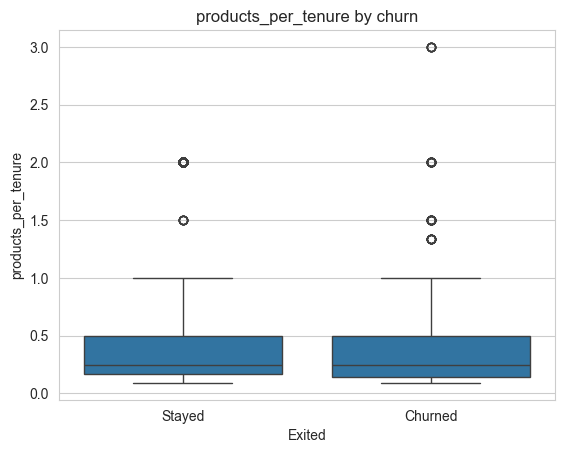

NumOfProducts correlation with Exited:        -0.0478
products_per_tenure correlation with Exited:  -0.0064


In [12]:
df["products_per_tenure"] = df["NumOfProducts"] / (df["Tenure"] + 1)

sns.boxplot(data=df, x="Exited", y="products_per_tenure")
plt.xticks([0, 1], ["Stayed", "Churned"])
plt.title("products_per_tenure by churn")
plt.show()

print(f"NumOfProducts correlation with Exited:        {df['NumOfProducts'].corr(df['Exited']):.4f}")
print(f"products_per_tenure correlation with Exited:  {df['products_per_tenure'].corr(df['Exited']):.4f}")

**Verdict: kept — directly inherits the strongest non-linear signal
in the dataset.**

`NumOfProducts` itself has a near-zero linear correlation (-0.048)
*despite* being the most dramatic pattern in Section 3 - that's the
non-linearity (2 products = safe, 3-4 = churn cliff) cancelling itself
out in a simple correlation coefficient. This is a good reminder that
correlation alone can hide important non-linear relationships.

`products_per_tenure` essentially passes that same cliff through, scaled
by tenure. A new customer (`Tenure=0`) who already has 3 products gets
the highest possible value of this feature (3/1 = 3.0) - which, per
Section 3, is close to a churn certainty. This feature ends up
**ranking #2 in SHAP importance** in `main.py` (after Age) — by far the
strongest of the four engineered features, and the clearest payoff
from this notebook's exploration.

## 6. Takeaways → what made it into `main.py`

| Feature | Standalone signal | Why kept |
|---|---|---|
| `products_per_tenure` | **Strong** (inherits the NumOfProducts cliff) | Clear win - top-2 SHAP driver |
| `credit_score_bucket` | Weak | Standard banking segmentation; low-cost to include |
| `balance_salary_ratio` | Moderate | Normalizes Balance, which itself is a real signal |
| `tenure_age_ratio` | Weak | Kept for interaction potential with Age; honestly the weakest of the four |

**Modeling implications carried into `main.py`:**

- **AUC-ROC over accuracy** - confirmed necessary by the 20% churn rate (Section 2)
- **Tree-based models prioritized** - the NumOfProducts cliff (Section 3) is
  exactly the kind of non-linear, threshold-based pattern Logistic Regression
  struggles with
- **SMOTE tested on training data only** - addresses the same imbalance from
  Section 2, evaluated against `class_weight='balanced'` as an alternative
- **Geography and IsActiveMember** flagged early as likely top features -
  both later confirmed in the SHAP results

Not every engineered feature turned out to be a top driver, and that's
shown honestly above (`tenure_age_ratio` in particular).
